FIRST 5 ROWS
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008

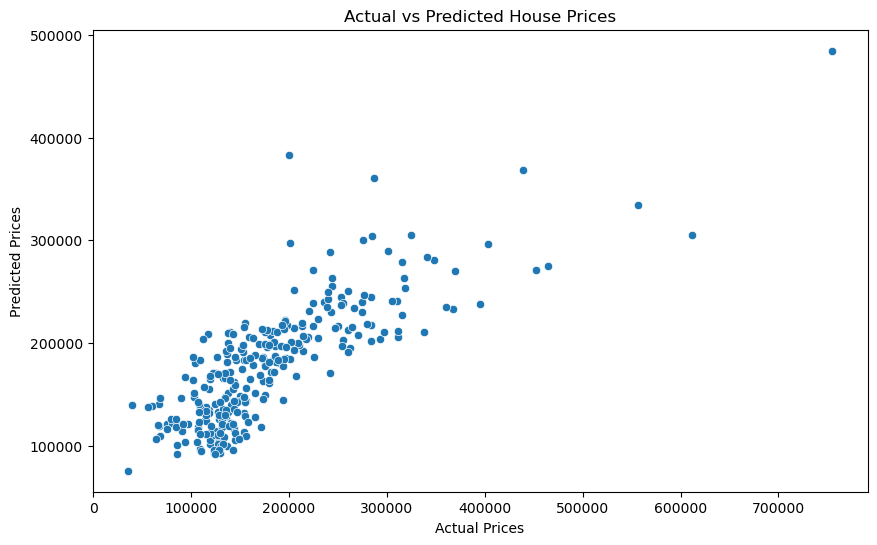

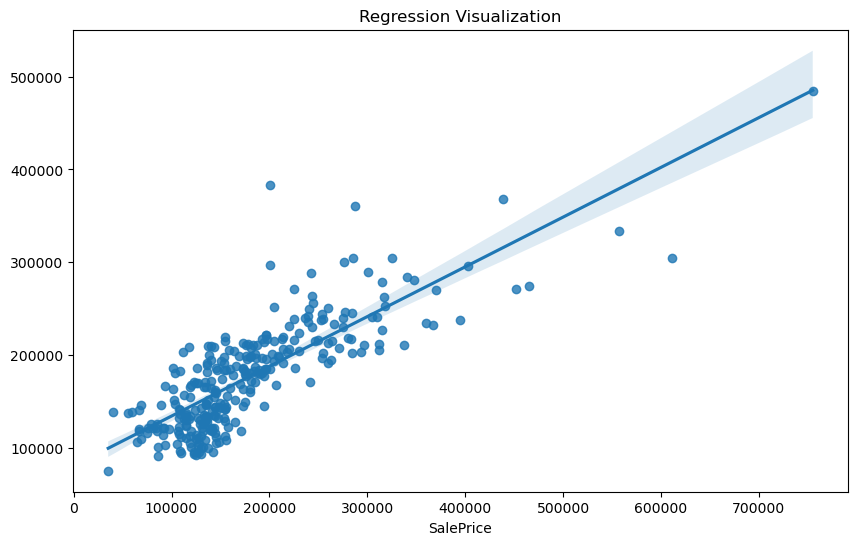


FEATURE COEFFICIENTS
        Feature   Coefficient
0     GrLivArea    104.026307
1  BedroomAbvGr -26655.165357
2      FullBath  30014.324109

NEW HOUSE PREDICTED PRICE
[240377.51479736]

PREDICTIONS SAVED SUCCESSFULLY


C:\Users\ravic\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
# ==========================================
# HOUSE PRICE PREDICTION
# LINEAR REGRESSION PROJECT
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# ------------------------------------------
# LOAD DATASET
# ------------------------------------------

df = pd.read_csv(
    "../../../datasets/raw/houseprice/train.csv"
)

# ------------------------------------------
# BASIC INFORMATION
# ------------------------------------------

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nMISSING VALUES")
print(df.isnull().sum())

# ------------------------------------------
# SELECT FEATURES
# ------------------------------------------

# Input Features
X = df[[
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath"
]]

# Target Column
y = df["SalePrice"]

# ------------------------------------------
# HANDLE MISSING VALUES
# ------------------------------------------

X = X.fillna(X.mean())

# ------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# CREATE MODEL
# ------------------------------------------

model = LinearRegression()

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

model.fit(
    X_train,
    y_train
)

# ------------------------------------------
# PREDICTIONS
# ------------------------------------------

predictions = model.predict(X_test)

print("\nPREDICTIONS")
print(predictions[:10])

# ------------------------------------------
# EVALUATION
# ------------------------------------------

mse = mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nMEAN SQUARED ERROR")
print(mse)

print("\nR2 SCORE")
print(r2)

# ------------------------------------------
# ACTUAL VS PREDICTED
# ------------------------------------------

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print("\nACTUAL VS PREDICTED")
print(results.head())

# ------------------------------------------
# VISUALIZATION
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=predictions
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.show()

# ------------------------------------------
# REGRESSION LINE VISUALIZATION
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    x=y_test,
    y=predictions
)

plt.title("Regression Visualization")

plt.show()

# ------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFEATURE COEFFICIENTS")
print(coefficients)

# ------------------------------------------
# PREDICT NEW HOUSE PRICE
# ------------------------------------------

new_house = [[2000, 3, 2]]

predicted_price = model.predict(
    new_house
)

print("\nNEW HOUSE PREDICTED PRICE")
print(predicted_price)

# ==========================================
# SAVE MODEL PREDICTIONS
# ==========================================

results.to_csv(
    "../../../datasets/processed/houseprice_predictions.csv",
    index=False
)

print("\nPREDICTIONS SAVED SUCCESSFULLY")

# ==========================================
# END
# ==========================================